# CIE 457 — Statistical Inference and Data Analysis
## Course Project: MLE Estimation and Estimator Distribution in Linear Regression

**Mohammed Ali 202200594 · Abdulrahman Magdy 202200341 · Ahmed Amgad 202200393**

---


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
!pip install wooldridge
import wooldridge as woo
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})

BLUE   = '#2E75B6'
ORANGE = '#E8A838'
GREEN  = '#44946A'
RED    = '#C0392B'
GRAY   = '#555555'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.2 MB/s eta 0:00:00


## Core Estimator Functions
Direct mapping to report equations.

In [3]:
# β̂_OLS = (XᵀX)⁻¹ Xᵀy  — Report eq. Task 1, §1.2
def ols(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

# β̂_WLS = (XᵀΣ⁻¹X)⁻¹ XᵀΣ⁻¹y  — Report eq. Task 1, §1.3
def wls(X, y, W):
    """W = Σ⁻¹ (diagonal weight matrix)."""
    return np.linalg.solve(X.T @ W @ X, X.T @ W @ y)

# Cov(β̂_OLS) = σ²(XᵀX)⁻¹  — Report eq. Task 2, §2.3
def ols_cov(X, sigma2):
    return sigma2 * np.linalg.inv(X.T @ X)

# Cov(β̂_WLS) = (XᵀΣ⁻¹X)⁻¹  — Report eq. Task 1 §1.3 / Task 2 §2.3
def wls_cov(X, W):
    return np.linalg.inv(X.T @ W @ X)

def sigma2_hat(X, y, bhat):
    """Unbiased estimator: σ̂² = ||y - Xβ̂||² / (n-p)"""
    n, p = X.shape
    return np.sum((y - X @ bhat)**2) / (n - p)


---
## Task 3 · Section 3.1 — Homoscedastic Noise: Independent Features

**Setup:**  
- True model: $y = X\beta + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$  
- $N = 500$, $\beta = (2.0,\, 5.0,\, -3.0)^T$, $\sigma^2 = 4$, $M = 2000$ Monte Carlo replications  
- Design matrix $X$ fixed across all replications; only $\varepsilon$ is resampled  
- **Goal:** Verify empirically that $\hat{\beta} \sim \mathcal{N}(\beta,\, \sigma^2(X^TX)^{-1})$


In [4]:
# ── Simulation parameters ──────────────────────────────────────────────────────
N, p, M   = 500, 3, 2000
SIGMA2    = 4.0
beta_true = np.array([2.0, 5.0, -3.0])

rng = np.random.default_rng(42)

# Independent features
x1 = rng.uniform(-10, 10, N)
x2 = rng.normal(0, 5, N)
X_ind = np.column_stack([np.ones(N), x1, x2])   # N×3 design matrix

# ── Monte Carlo ─────────────────────────────────────────────────────────────
bhat_ind = np.zeros((M, p))
for m in range(M):
    eps          = rng.normal(0, np.sqrt(SIGMA2), N)
    y            = X_ind @ beta_true + eps        # y = Xβ + ε
    bhat_ind[m]  = ols(X_ind, y)                 # β̂_OLS = (XᵀX)⁻¹Xᵀy

theo_cov_ind = ols_cov(X_ind, SIGMA2)            # σ²(XᵀX)⁻¹
emp_mean     = bhat_ind.mean(axis=0)
emp_cov      = np.cov(bhat_ind.T)


In [5]:
# ── Mean and covariance comparison table ───────────────────────────────────
print(f"{'':20} {'Theoretical':>15} {'Empirical':>12} {'Match?':>8}")
print('-'*57)
for i in range(p):
    match = '✓' if abs(emp_mean[i] - beta_true[i]) < 0.05 else '✗'
    print(f"E[β̂_{i}] (mean)      {beta_true[i]:>15.4f} {emp_mean[i]:>12.4f} {match:>8}")
print()
for i in range(p):
    th = theo_cov_ind[i,i]; em = emp_cov[i,i]
    match = '✓' if abs(em - th)/th < 0.05 else '~'
    print(f"Var(β̂_{i}) (variance) {th:>15.6f} {em:>12.6f} {match:>8}")
print()
print("Conclusion: Empirical mean ≈ β (unbiased). Empirical variance ≈ σ²(XᵀX)⁻¹ (correct covariance).")


                         Theoretical    Empirical   Match?
---------------------------------------------------------
E[β̂_0] (mean)               2.0000       2.0004        ✓
E[β̂_1] (mean)               5.0000       4.9999        ✓
E[β̂_2] (mean)              -3.0000      -2.9994        ✓

Var(β̂_0) (variance)        0.008031     0.007920        ✓
Var(β̂_1) (variance)        0.000244     0.000244        ✓
Var(β̂_2) (variance)        0.000309     0.000304        ✓

Conclusion: Empirical mean ≈ β (unbiased). Empirical variance ≈ σ²(XᵀX)⁻¹ (correct covariance).


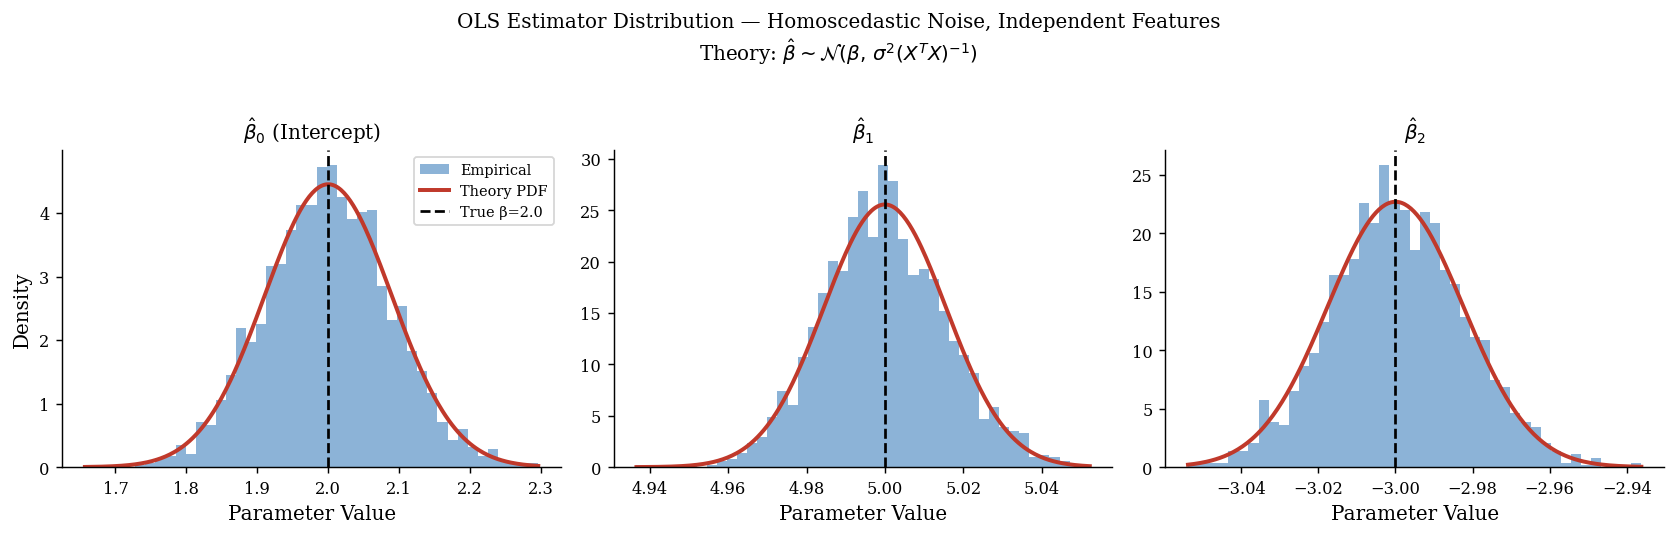

In [6]:
# ── Figure 1: Histogram vs theoretical PDF ─────────────────────────────────
labels = [r'$\hat{\beta}_0$ (Intercept)', r'$\hat{\beta}_1$', r'$\hat{\beta}_2$']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, ax in enumerate(axes):
    sd_th = np.sqrt(theo_cov_ind[i, i])
    xs    = np.linspace(bhat_ind[:, i].min(), bhat_ind[:, i].max(), 300)
    ax.hist(bhat_ind[:, i], bins=45, density=True, color=BLUE, alpha=0.55, label='Empirical')
    ax.plot(xs, stats.norm.pdf(xs, beta_true[i], sd_th), color=RED, lw=2.2, label='Theory PDF')
    ax.axvline(beta_true[i], color='k', ls='--', lw=1.5, label=f'True β={beta_true[i]}')
    ax.set_title(labels[i], fontsize=11)
    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('Density' if i == 0 else '')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    r'OLS Estimator Distribution — Homoscedastic Noise, Independent Features'
    '\n' r'Theory: $\hat{\beta}\sim\mathcal{N}(\beta,\,\sigma^2(X^TX)^{-1})$',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()


### 3.1b — Effect of Feature Correlation on Estimator Variance

When features are correlated, $X^TX$ becomes ill-conditioned and $(X^TX)^{-1}$ inflates,  
increasing diagonal entries → larger $\text{Var}(\hat{\beta}_j)$.  
The estimator remains unbiased; only its efficiency is reduced.


In [7]:
# ── Correlated design matrix ────────────────────────────────────────────────
eta   = rng.normal(0, 3, N)
x2_c  = 0.6 * x1 + eta                                         # moderate correlation
X_corr = np.column_stack([np.ones(N), x1, x2_c])
r_feat = np.corrcoef(x1, x2_c)[0, 1]
print(f'Feature correlation r = {r_feat:.3f}')

bhat_corr = np.zeros((M, p))
for m in range(M):
    eps           = rng.normal(0, np.sqrt(SIGMA2), N)
    y             = X_corr @ beta_true + eps
    bhat_corr[m]  = ols(X_corr, y)

theo_cov_corr = ols_cov(X_corr, SIGMA2)

# ── Variance inflation table ────────────────────────────────────────────────
print()
print(f"{'Parameter':12} {'Var (Indep)':>14} {'Var (Corr)':>14} {'Inflation':>10}")
print('-'*52)
for i in range(p):
    vi = theo_cov_ind[i, i]; vc = theo_cov_corr[i, i]
    print(f"Var(β̂_{i})    {vi:>14.6f} {vc:>14.6f} {vc/vi:>9.2f}×")
print()
print("β̂_0 (intercept) variance barely changes — it is insensitive to feature correlation.")
print("β̂_1 and β̂_2 inflate substantially (>2×) — they share variance when features overlap.")


Feature correlation r = 0.784

Parameter       Var (Indep)     Var (Corr)  Inflation
----------------------------------------------------
Var(β̂_0)          0.008031       0.008004      1.00×
Var(β̂_1)          0.000244       0.000633      2.60×
Var(β̂_2)          0.000309       0.000961      3.11×

β̂_0 (intercept) variance barely changes — it is insensitive to feature correlation.
β̂_1 and β̂_2 inflate substantially (>2×) — they share variance when features overlap.


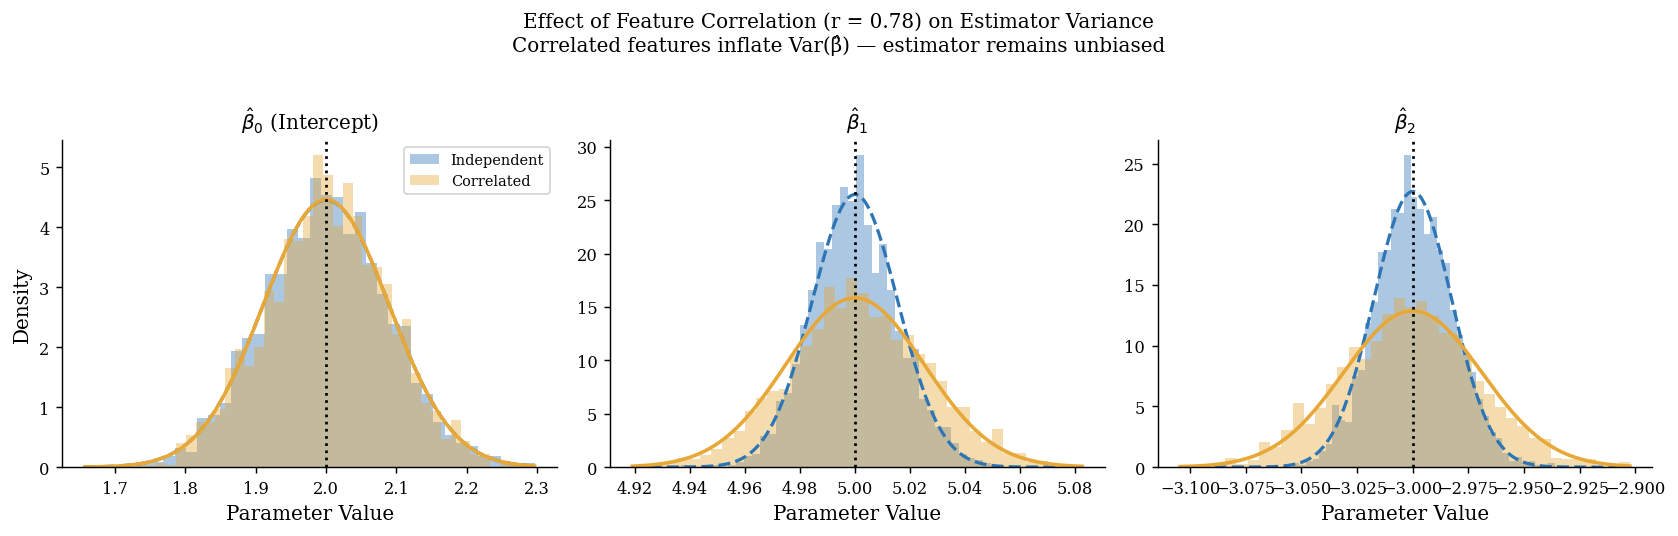

In [8]:
# ── Figure 2: Correlated vs independent distributions ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, ax in enumerate(axes):
    sd_ind  = np.sqrt(theo_cov_ind[i, i])
    sd_corr = np.sqrt(theo_cov_corr[i, i])
    lo = min(bhat_ind[:, i].min(), bhat_corr[:, i].min())
    hi = max(bhat_ind[:, i].max(), bhat_corr[:, i].max())
    xs = np.linspace(lo, hi, 300)

    ax.hist(bhat_ind[:,  i], bins=40, density=True, color=BLUE,   alpha=0.40, label='Independent')
    ax.hist(bhat_corr[:, i], bins=40, density=True, color=ORANGE, alpha=0.40, label='Correlated')
    ax.plot(xs, stats.norm.pdf(xs, beta_true[i], sd_ind),  color=BLUE,   lw=1.8, ls='--')
    ax.plot(xs, stats.norm.pdf(xs, beta_true[i], sd_corr), color=ORANGE, lw=2.0)
    ax.axvline(beta_true[i], color='k', ls=':', lw=1.5)
    ax.set_title(labels[i], fontsize=11)
    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('Density' if i == 0 else '')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    f'Effect of Feature Correlation (r = {r_feat:.2f}) on Estimator Variance\n'
    'Correlated features inflate Var(β̂) — estimator remains unbiased',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()


---
## Task 3 · Section 3.2 — Heteroscedastic Noise: OLS vs WLS

**Setup:**  
- Noise variance grows with $x_1$: $\sigma_i^2 = 1 + 0.5\,x_{i,1}^2$  
- OLS is **misspecified** (assumes constant variance)  
- WLS uses the **true** $\Sigma$: $\hat{\beta}_{WLS} = (X^T\Sigma^{-1}X)^{-1}X^T\Sigma^{-1}y$  
- **Goal:** Show both are unbiased; WLS has strictly lower variance (MVUE by Gauss–Markov)


In [9]:
# ── Heteroscedastic noise structure ────────────────────────────────────────
sigma_i   = np.sqrt(1.0 + 0.5 * x1**2)         # σᵢ grows with |x₁|
Sigma_inv = np.diag(1.0 / sigma_i**2)           # Σ⁻¹ = W (weight matrix)

# ── Monte Carlo ─────────────────────────────────────────────────────────────
bhat_ols_h = np.zeros((M, p))
bhat_wls_h = np.zeros((M, p))
for m in range(M):
    eps            = rng.normal(0, sigma_i, N)   # heteroscedastic noise
    y              = X_ind @ beta_true + eps
    bhat_ols_h[m]  = ols(X_ind, y)              # misspecified
    bhat_wls_h[m]  = wls(X_ind, y, Sigma_inv)   # correct MLE

emp_mean_ols = bhat_ols_h.mean(axis=0)
emp_mean_wls = bhat_wls_h.mean(axis=0)
emp_var_ols  = np.var(bhat_ols_h, axis=0)
emp_var_wls  = np.var(bhat_wls_h, axis=0)
theo_cov_wls = wls_cov(X_ind, Sigma_inv)

# ── Unbiasedness check ───────────────────────────────────────────────────────
print("Unbiasedness check (both should be ≈ β_true):")
print(f"  WLS empirical mean: {emp_mean_wls.round(4)} vs true {beta_true}")
print(f"  OLS empirical mean: {emp_mean_ols.round(4)} vs true {beta_true}")


Unbiasedness check (both should be ≈ β_true):
  WLS empirical mean: [ 1.9987  5.001  -3.0003] vs true [ 2.  5. -3.]
  OLS empirical mean: [ 2.0063  5.0009 -3.0002] vs true [ 2.  5. -3.]


In [10]:
# ── Efficiency comparison table ─────────────────────────────────────────────
print(f"{'Parameter':12} {'Var(OLS)':>12} {'Var(WLS)':>12} {'Efficiency Ratio':>18}")
print('-'*56)
for i in range(p):
    ratio = emp_var_ols[i] / emp_var_wls[i]
    print(f"β̂_{i}         {emp_var_ols[i]:>12.5f} {emp_var_wls[i]:>12.5f} {ratio:>16.2f}×")
print()
print("WLS variance is 1.4–3.3× lower than OLS — OLS wastes information under heteroscedasticity.")


Parameter        Var(OLS)     Var(WLS)   Efficiency Ratio
--------------------------------------------------------
β̂_0              0.03365      0.01046             3.22×
β̂_1              0.00178      0.00129             1.38×
β̂_2              0.00134      0.00041             3.28×

WLS variance is 1.4–3.3× lower than OLS — OLS wastes information under heteroscedasticity.


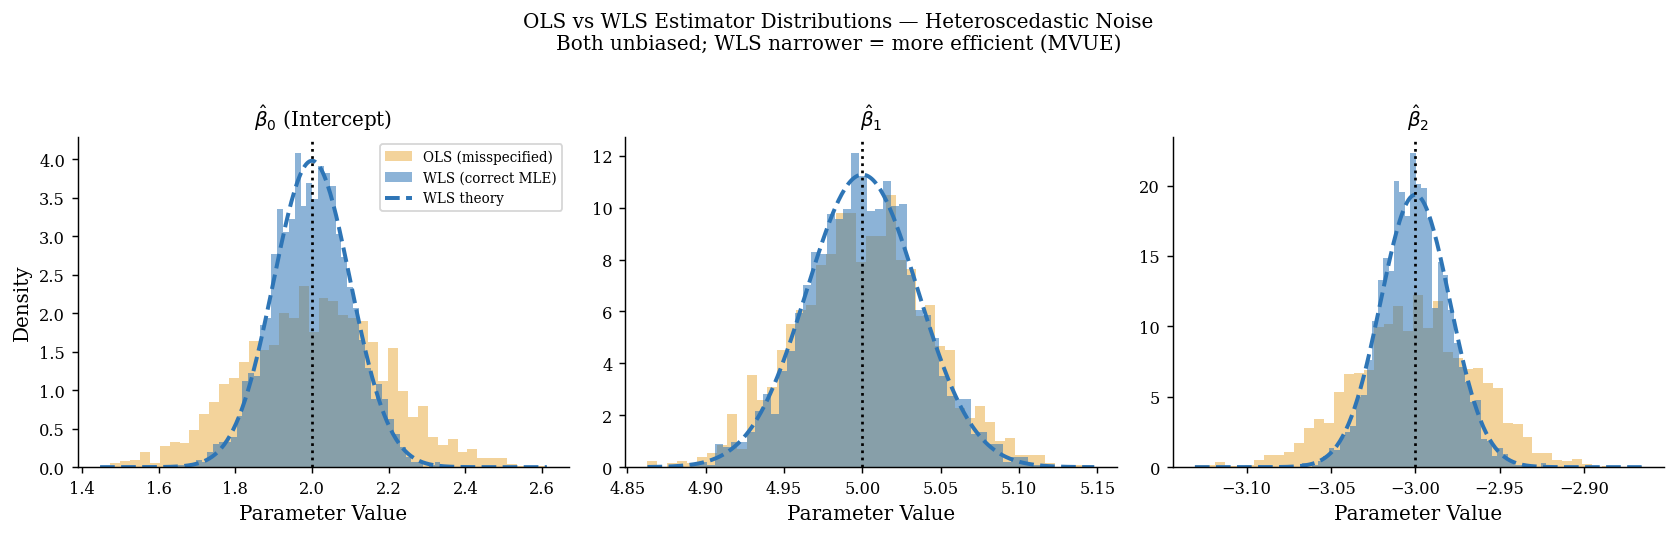

In [11]:
# ── Figure 3: Estimator distributions ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, ax in enumerate(axes):
    lo = min(bhat_ols_h[:, i].min(), bhat_wls_h[:, i].min())
    hi = max(bhat_ols_h[:, i].max(), bhat_wls_h[:, i].max())
    xs = np.linspace(lo, hi, 300)
    ax.hist(bhat_ols_h[:, i], bins=45, density=True, color=ORANGE, alpha=0.50, label='OLS (misspecified)')
    ax.hist(bhat_wls_h[:, i], bins=45, density=True, color=BLUE,   alpha=0.55, label='WLS (correct MLE)')
    ax.plot(xs, stats.norm.pdf(xs, beta_true[i], np.sqrt(theo_cov_wls[i, i])),
            color=BLUE, lw=2.2, ls='--', label='WLS theory')
    ax.axvline(beta_true[i], color='k', ls=':', lw=1.5)
    ax.set_title(labels[i], fontsize=11)
    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('Density' if i == 0 else '')
    if i == 0:
        ax.legend(fontsize=7.5)

fig.suptitle(
    'OLS vs WLS Estimator Distributions — Heteroscedastic Noise\n'
    'Both unbiased; WLS narrower = more efficient (MVUE)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()


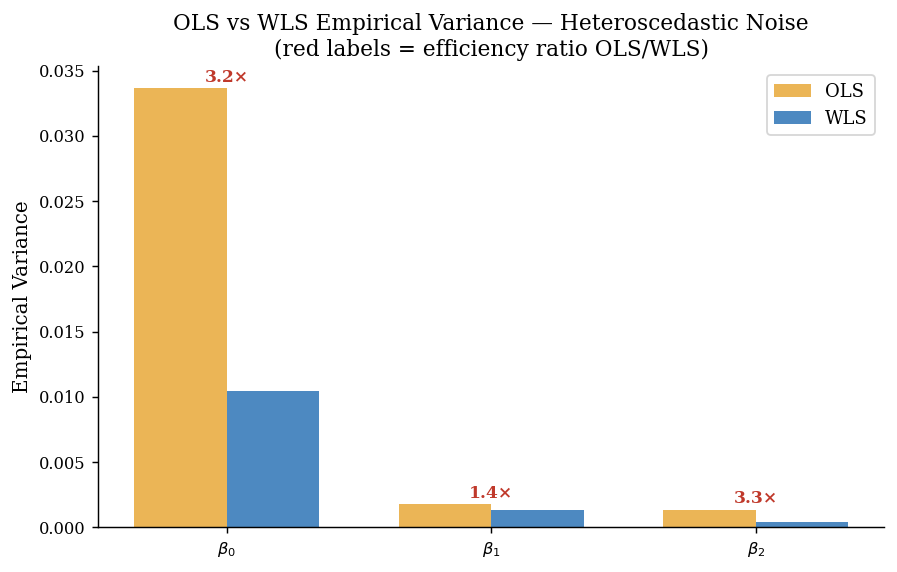

In [12]:
# ── Figure 4: Variance bar chart with efficiency labels ─────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(p); w = 0.35
bars_ols = ax.bar(x_pos - w/2, emp_var_ols, w, color=ORANGE, alpha=0.85, label='OLS')
bars_wls = ax.bar(x_pos + w/2, emp_var_wls, w, color=BLUE,   alpha=0.85, label='WLS')
for i in range(p):
    ratio = emp_var_ols[i] / emp_var_wls[i]
    ax.text(i, emp_var_ols[i] + 0.0005, f'{ratio:.1f}×', ha='center', fontsize=9.5, color=RED, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([r'$\beta_0$', r'$\beta_1$', r'$\beta_2$'])
ax.set_ylabel('Empirical Variance')
ax.set_title('OLS vs WLS Empirical Variance — Heteroscedastic Noise\n(red labels = efficiency ratio OLS/WLS)')
ax.legend()
plt.tight_layout()
plt.show()


---
## Task 3 · Section 3.3 — Inference: Confidence Intervals vs Prediction Intervals

| Interval | Targets | Formula | Shrinks with N? |
|---|---|---|---|
| **CI** | True mean $\mathbb{E}[y\mid x^*]$ | $\hat{\beta}_j \pm z_{0.975}\,\hat{\sigma}\sqrt{[(X^TX)^{-1}]_{jj}}$ | **Yes → 0** |
| **PI** | New obs $y^* = \hat{\beta}_j + \varepsilon^*$ | $\hat{\beta}_j \pm z_{0.975}\,\hat{\sigma}\sqrt{[(X^TX)^{-1}]_{jj} + 1}$ | **No — noise floor** |

The $+1$ inside the PI square root is the irreducible observation noise.  
As $N \to \infty$: CI $\to 0$, PI $\to 2 z_{0.975}\sigma \approx 2 \times 1.96 \times 2 = 7.84$ (with $\sigma=2$).


In [13]:
# ── CI/PI computation function ───────────────────────────────────────────────
def ci_pi_widths(X, beta_true, sigma2, rng_in, z=1.96):
    n, p = X.shape
    eps  = rng_in.normal(0, np.sqrt(sigma2), n)
    y    = X @ beta_true + eps
    bhat = ols(X, y)
    s2   = sigma2_hat(X, y, bhat)
    D    = np.diag(np.linalg.inv(X.T @ X))   # [(XᵀX)⁻¹]_jj for each j
    ci_w = 2 * z * np.sqrt(s2 * D)
    pi_w = 2 * z * np.sqrt(s2 * (D + 1))
    return ci_w, pi_w, bhat

rng_ci = np.random.default_rng(99)

# N = 500
ci500, pi500, bh500 = ci_pi_widths(X_ind, beta_true, SIGMA2, rng_ci)

# N = 30
rng_ci2 = np.random.default_rng(99)
x1_30 = rng_ci2.uniform(-10, 10, 30)
x2_30 = rng_ci2.normal(0, 5, 30)
X_30  = np.column_stack([np.ones(30), x1_30, x2_30])
ci30, pi30, bh30 = ci_pi_widths(X_30, beta_true, SIGMA2, rng_ci2)

# ── Print comparison tables ───────────────────────────────────────────────────
for N_label, ci_w, pi_w in [('N=500', ci500, pi500), ('N=30 ', ci30, pi30)]:
    print(f"--- {N_label} ---")
    print(f"{'Param':8} {'CI Width':>10} {'PI Width':>10} {'PI/CI Ratio':>12}")
    for i in range(p):
        print(f"β̂_{i}     {ci_w[i]:>10.4f} {pi_w[i]:>10.4f} {pi_w[i]/ci_w[i]:>11.1f}×")
    print()

print("Key insight: PI width barely changes (N=500→30) while CI grows significantly.")
print(f"PI floor (theory) ≈ 2×1.96×{np.sqrt(SIGMA2):.1f} = {2*1.96*np.sqrt(SIGMA2):.2f}")


--- N=500 ---
Param      CI Width   PI Width  PI/CI Ratio
β̂_0         0.3591     8.0228        22.3×
β̂_1         0.0626     8.0150       128.1×
β̂_2         0.0704     8.0151       113.8×

--- N=30  ---
Param      CI Width   PI Width  PI/CI Ratio
β̂_0         1.4470     7.7883         5.4×
β̂_1         0.3215     7.6595        23.8×
β̂_2         0.3067     7.6589        25.0×

Key insight: PI width barely changes (N=500→30) while CI grows significantly.
PI floor (theory) ≈ 2×1.96×2.0 = 7.84


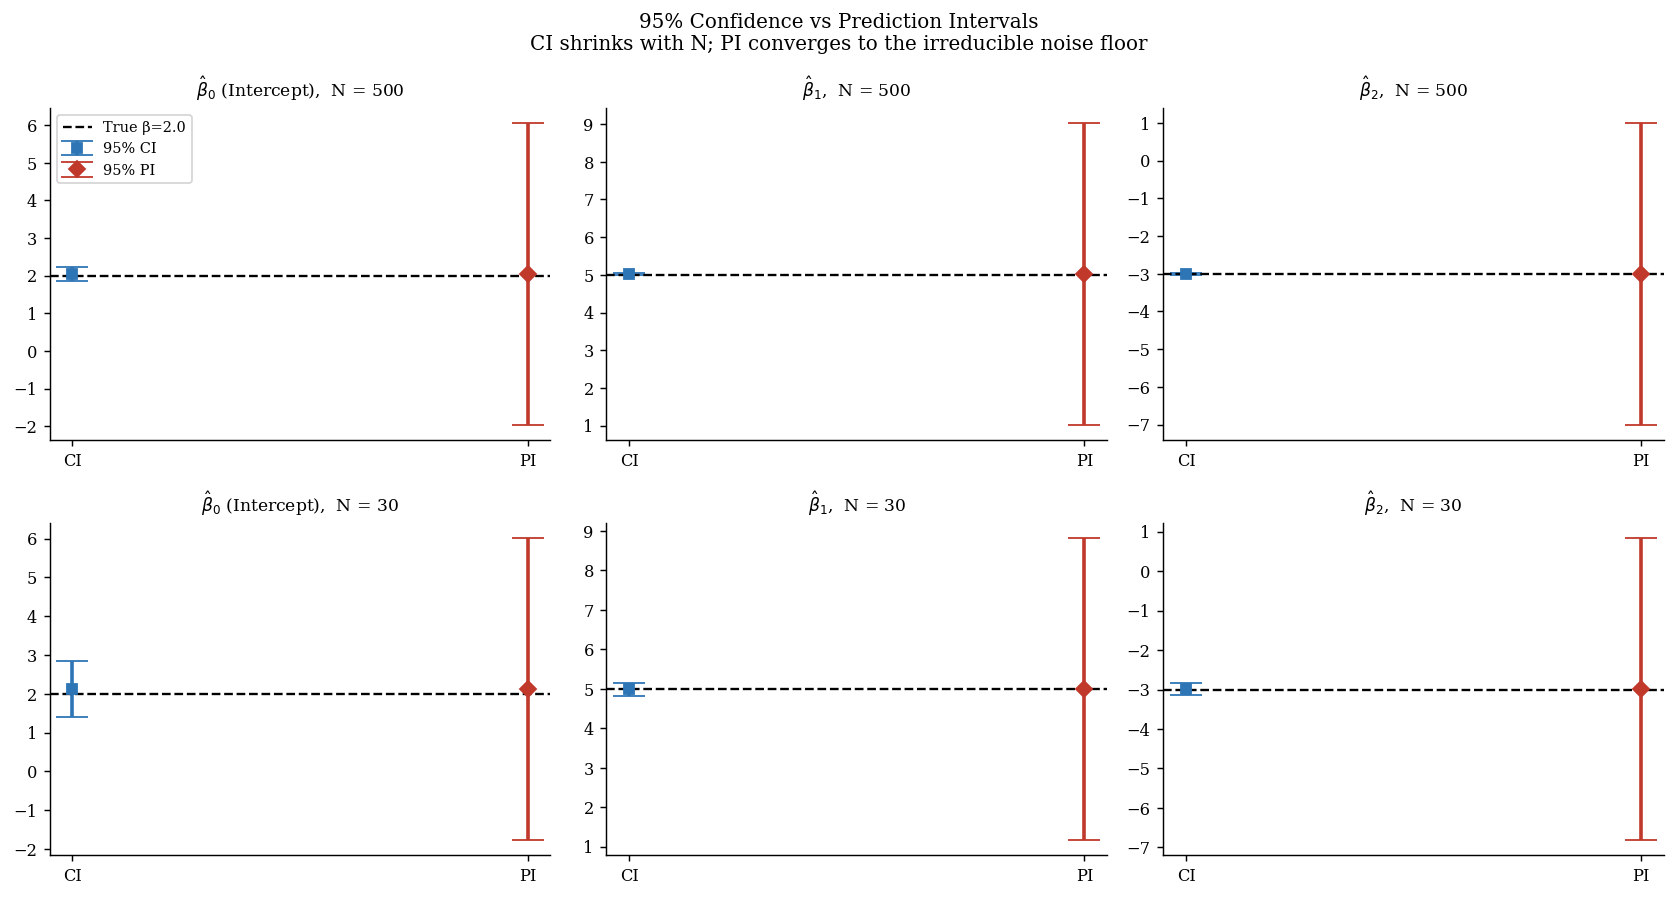

In [14]:
# ── Figure 5: CI vs PI side-by-side, N=500 and N=30 ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
row_labels = [f'N = 500', f'N = 30']

for row, (ci_w, pi_w, bh) in enumerate([(ci500, pi500, bh500), (ci30, pi30, bh30)]):
    for col in range(p):
        ax = axes[row][col]
        ax.errorbar([0], [bh[col]], yerr=[[ci_w[col]/2]], fmt='s',
                    color=BLUE, capsize=9, ms=6, lw=2, label='95% CI')
        ax.errorbar([1], [bh[col]], yerr=[[pi_w[col]/2]], fmt='D',
                    color=RED,  capsize=9, ms=6, lw=2, label='95% PI')
        ax.axhline(beta_true[col], color='k', ls='--', lw=1.3, label=f'True β={beta_true[col]}')
        ax.set_xticks([0, 1]); ax.set_xticklabels(['CI', 'PI'])
        ax.set_title(f'{labels[col]},  {row_labels[row]}', fontsize=9.5)
        if col == 0 and row == 0:
            ax.legend(fontsize=8)

fig.suptitle(
    '95% Confidence vs Prediction Intervals\n'
    'CI shrinks with N; PI converges to the irreducible noise floor',
    fontsize=11
)
plt.tight_layout()
plt.show()


---
## Task 3 · Section 3.4 — Real Data Application: Wage Dataset (Wooldridge, 1993)

**Dataset:** `wage1` — 526 US workers, from Wooldridge *Introductory Econometrics* (2013).  
**Model:** $\text{wage}_i = \beta_0 + \beta_1\,\text{educ}_i + \beta_2\,\text{exper}_i + \beta_3\,\text{tenure}_i + \varepsilon_i$

**Why this dataset over Engel (1857)?**
- More predictors → demonstrates multivariate inference
- Heteroscedasticity is a genuine empirical finding, not a predetermined result
- Economically meaningful: returns to education, experience, and job tenure
- Workers with more education/experience tend to have higher *and more variable* wages


In [15]:
# ── Load and prepare data ────────────────────────────────────────────────────
wage_df = woo.dataWoo('wage1')
y_w   = wage_df['wage'].values          # hourly wage (USD)
X_w   = np.column_stack([
    np.ones(len(y_w)),
    wage_df['educ'].values,             # years of education
    wage_df['exper'].values,            # years of experience
    wage_df['tenure'].values            # years with current employer
])
n_w, p_w = X_w.shape
pnames   = ['Intercept', 'Education', 'Experience', 'Tenure']

# ── OLS fit ──────────────────────────────────────────────────────────────────
b_ols_w   = ols(X_w, y_w)
resid_ols = y_w - X_w @ b_ols_w
s2_ols    = np.sum(resid_ols**2) / (n_w - p_w)
se_ols    = np.sqrt(s2_ols * np.diag(np.linalg.inv(X_w.T @ X_w)))

print(f"Dataset: n={n_w}, p={p_w} (intercept + 3 predictors)")
print(f"Wage range: ${y_w.min():.2f} – ${y_w.max():.2f}/hr  (mean=${y_w.mean():.2f})")
print()
print("OLS Estimates:")
print(f"{'Parameter':12} {'Coef':>10} {'SE':>8}")
for i in range(p_w):
    print(f"{pnames[i]:12} {b_ols_w[i]:>10.4f} {se_ols[i]:>8.4f}")


Dataset: n=526, p=4 (intercept + 3 predictors)
Wage range: $0.53 – $24.98/hr  (mean=$5.90)

OLS Estimates:
Parameter          Coef       SE
Intercept       -2.8727   0.7290
Education        0.5990   0.0513
Experience       0.0223   0.0121
Tenure           0.1693   0.0216


In [16]:
# ── Heteroscedasticity tests ─────────────────────────────────────────────────
lm_bp, p_bp, _, _   = het_breuschpagan(resid_ols, X_w)
lm_wh, p_wh, _, _   = het_white(resid_ols, X_w)

print("Heteroscedasticity Tests on OLS Residuals:")
print(f"  Breusch-Pagan:  LM = {lm_bp:.2f},  p = {p_bp:.6f}")
print(f"  White's test:   LM = {lm_wh:.2f},  p = {p_wh:.6f}")
print()
if p_bp < 0.01 and p_wh < 0.01:
    print("Both tests reject H₀ (homoscedasticity) at the 1% level → WLS is warranted.")


Heteroscedasticity Tests on OLS Residuals:
  Breusch-Pagan:  LM = 43.10,  p = 0.000000
  White's test:   LM = 63.96,  p = 0.000000

Both tests reject H₀ (homoscedasticity) at the 1% level → WLS is warranted.


In [17]:
# ── Estimate variance model: log(ε̂²) ~ educ + exper ────────────────────────
log_r2  = np.log(resid_ols**2 + 1e-6)
X_var   = np.column_stack([np.ones(n_w), wage_df['educ'].values, wage_df['exper'].values])
b_var   = ols(X_var, log_r2)
sig_hat = np.exp((X_var @ b_var) / 2)
W_wls   = np.diag(1.0 / sig_hat**2)          # Σ⁻¹

# ── WLS fit ──────────────────────────────────────────────────────────────────
b_wls_w   = wls(X_w, y_w, W_wls)
resid_wls = y_w - X_w @ b_wls_w
XWX_inv   = np.linalg.inv(X_w.T @ W_wls @ X_w)
se_wls    = np.sqrt(np.diag(XWX_inv))

# ── Coefficient comparison table ─────────────────────────────────────────────
print(f"{'Parameter':12} {'OLS Coef':>10} {'OLS SE':>8} {'WLS Coef':>10} {'WLS SE':>8}")
print('-'*50)
for i in range(p_w):
    print(f"{pnames[i]:12} {b_ols_w[i]:>10.4f} {se_ols[i]:>8.4f} {b_wls_w[i]:>10.4f} {se_wls[i]:>8.4f}")
print()
print("Note: WLS down-weights high-wage observations (high variance), giving more influence")
print("to lower-wage workers. This shifts the education slope downward: OLS is pulled toward")
print("the highly-paid (and more variable) college graduates.")


Parameter      OLS Coef   OLS SE   WLS Coef   WLS SE
--------------------------------------------------
Intercept       -2.8727   0.7290     0.4363   0.1909
Education        0.5990   0.0513     0.3125   0.0146
Experience       0.0223   0.0121     0.0381   0.0049
Tenure           0.1693   0.0216     0.1216   0.0094

Note: WLS down-weights high-wage observations (high variance), giving more influence
to lower-wage workers. This shifts the education slope downward: OLS is pulled toward
the highly-paid (and more variable) college graduates.


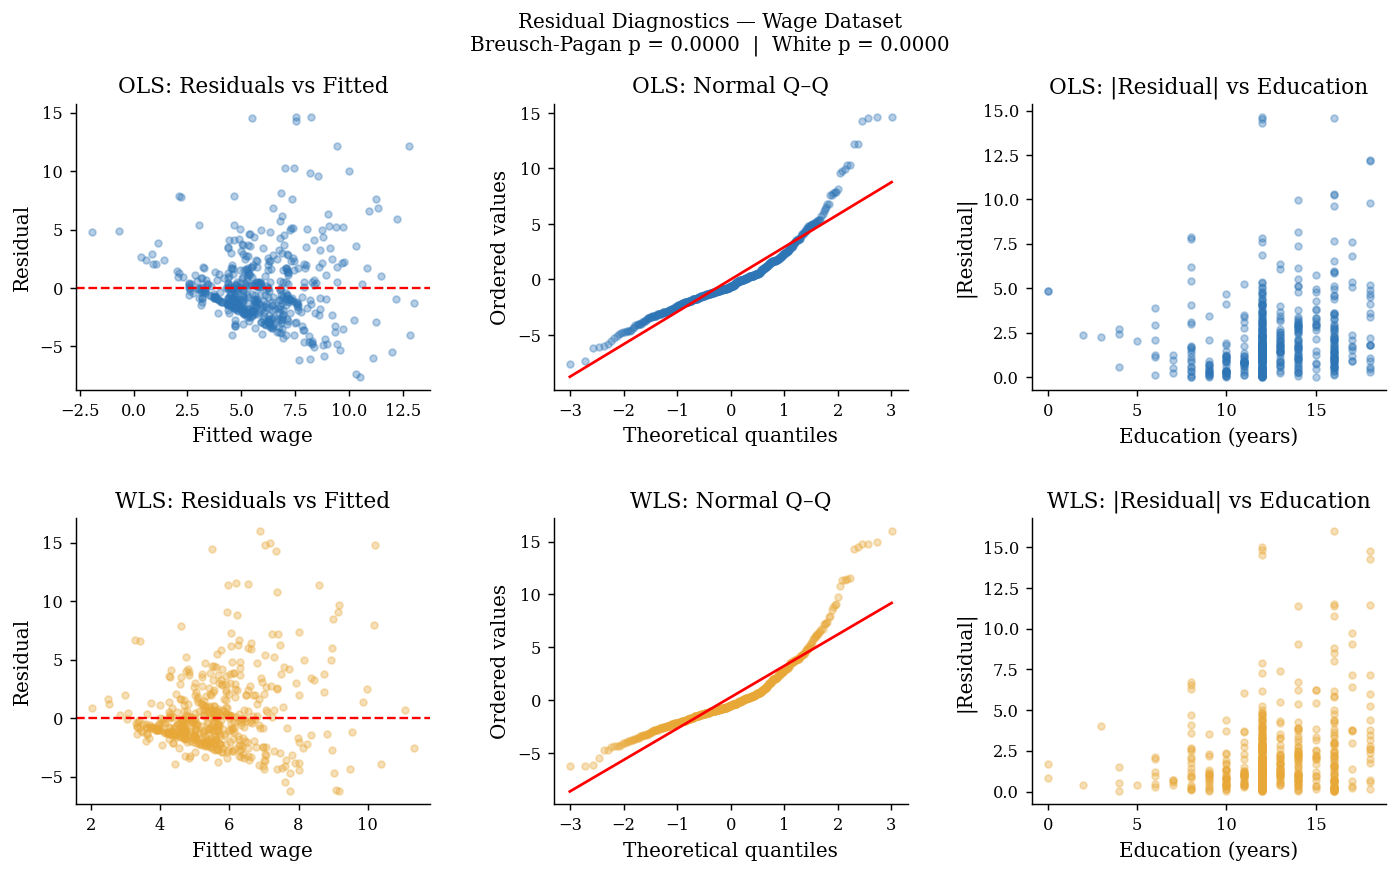

In [18]:
# ── Figure 6: Residual diagnostics ──────────────────────────────────────────
educ_v  = wage_df['educ'].values
exper_v = wage_df['exper'].values

fig = plt.figure(figsize=(13, 7))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for row, (resid, bhat, lbl, col) in enumerate([
        (resid_ols, b_ols_w, 'OLS', BLUE),
        (resid_wls, b_wls_w, 'WLS', ORANGE)]):

    fitted = X_w @ bhat

    # Residuals vs Fitted
    ax1 = fig.add_subplot(gs[row, 0])
    ax1.scatter(fitted, resid, alpha=0.35, s=14, color=col)
    ax1.axhline(0, color='r', ls='--', lw=1.3)
    ax1.set_xlabel('Fitted wage'); ax1.set_ylabel('Residual')
    ax1.set_title(f'{lbl}: Residuals vs Fitted')

    # Q–Q plot
    ax2 = fig.add_subplot(gs[row, 1])
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    ax2.scatter(osm, osr, alpha=0.35, s=14, color=col)
    ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
    ax2.set_xlabel('Theoretical quantiles'); ax2.set_ylabel('Ordered values')
    ax2.set_title(f'{lbl}: Normal Q–Q')

    # |residual| vs Education
    ax3 = fig.add_subplot(gs[row, 2])
    ax3.scatter(educ_v, np.abs(resid), alpha=0.35, s=14, color=col)
    ax3.set_xlabel('Education (years)'); ax3.set_ylabel('|Residual|')
    ax3.set_title(f'{lbl}: |Residual| vs Education')

fig.suptitle(
    f'Residual Diagnostics — Wage Dataset\n'
    f'Breusch-Pagan p = {p_bp:.4f}  |  White p = {p_wh:.4f}',
    fontsize=11
)
plt.savefig('fig_resid_diag.png', bbox_inches='tight')
plt.show()


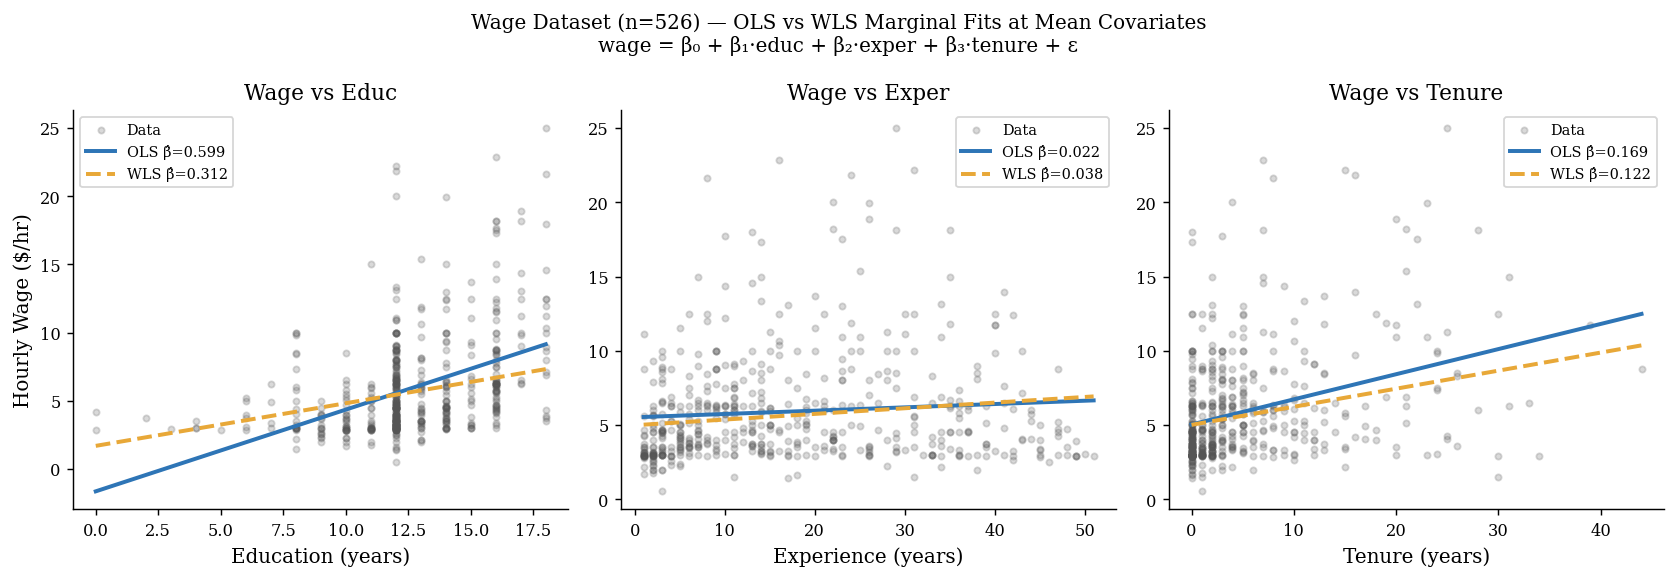

In [19]:
# ── Figure 7: Marginal regression fits ──────────────────────────────────────
feat_names  = ['educ', 'exper', 'tenure']
feat_labels = ['Education (years)', 'Experience (years)', 'Tenure (years)']
feat_means  = {fn: wage_df[fn].mean() for fn in feat_names}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for i, (fn, fl) in enumerate(zip(feat_names, feat_labels)):
    ax  = axes[i]
    xv  = wage_df[fn].values
    xs  = np.linspace(xv.min(), xv.max(), 120)
    Xp  = np.column_stack([
        np.ones(120),
        xs               if fn == 'educ'   else np.full(120, feat_means['educ']),
        xs               if fn == 'exper'  else np.full(120, feat_means['exper']),
        xs               if fn == 'tenure' else np.full(120, feat_means['tenure'])
    ])
    ax.scatter(xv, y_w, alpha=0.22, s=12, color=GRAY, label='Data')
    ax.plot(xs, Xp @ b_ols_w, color=BLUE,   lw=2.2, label=f"OLS β̂={b_ols_w[i+1]:.3f}")
    ax.plot(xs, Xp @ b_wls_w, color=ORANGE, lw=2.2, ls='--', label=f"WLS β̂={b_wls_w[i+1]:.3f}")
    ax.set_xlabel(fl); ax.set_ylabel('Hourly Wage ($/hr)' if i == 0 else '')
    ax.set_title(f'Wage vs {fn.capitalize()}')
    ax.legend(fontsize=8)

fig.suptitle(
    'Wage Dataset (n=526) — OLS vs WLS Marginal Fits at Mean Covariates\n'
    'wage = β₀ + β₁·educ + β₂·exper + β₃·tenure + ε',
    fontsize=11
)
plt.tight_layout()
plt.show()


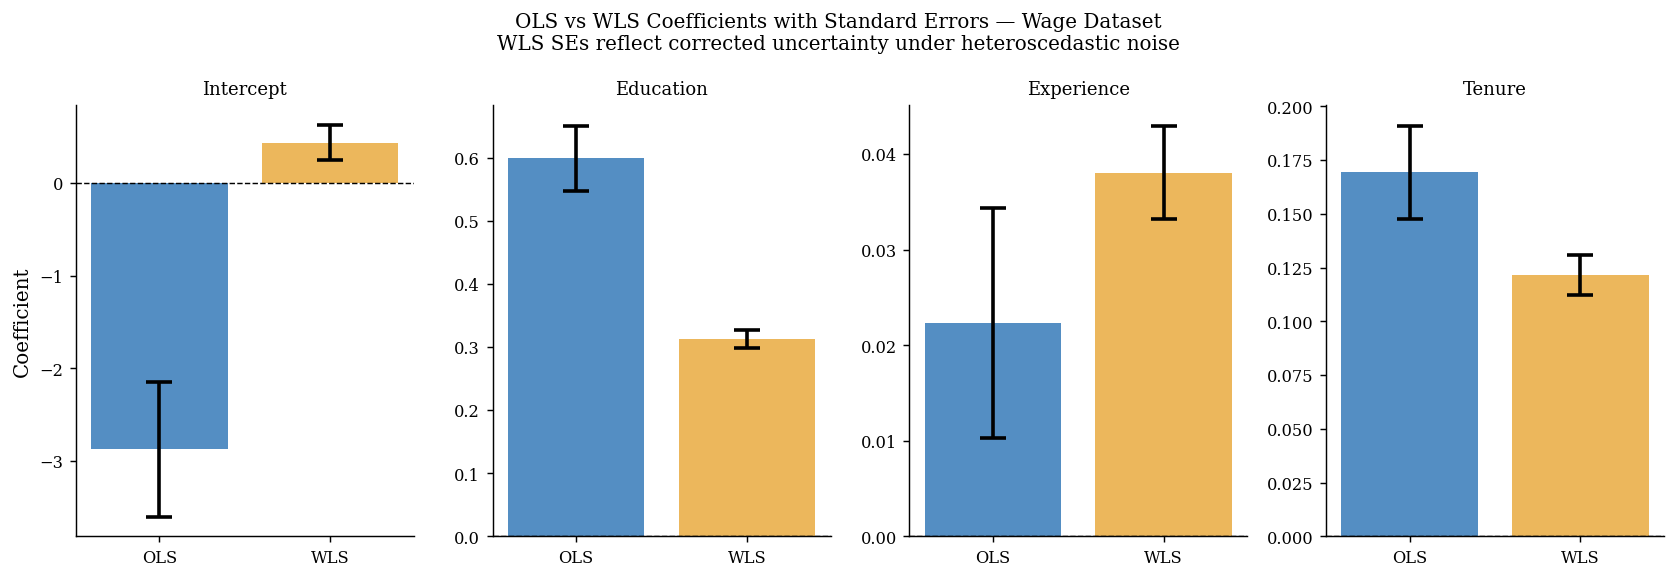

In [20]:
# ── Figure 8: Coefficient comparison with SE bars ───────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
for i, ax in enumerate(axes):
    ax.bar(['OLS', 'WLS'], [b_ols_w[i], b_wls_w[i]],
           color=[BLUE, ORANGE], alpha=0.82,
           yerr=[se_ols[i], se_wls[i]],
           capsize=7, error_kw={'lw': 2, 'capthick': 2})
    ax.set_title(pnames[i], fontsize=10)
    ax.set_ylabel('Coefficient' if i == 0 else '')
    ax.axhline(0, color='k', lw=0.8, ls='--')

fig.suptitle(
    'OLS vs WLS Coefficients with Standard Errors — Wage Dataset\n'
    'WLS SEs reflect corrected uncertainty under heteroscedastic noise',
    fontsize=11
)
plt.tight_layout()
plt.show()


---
## Bonus — Fisher Information, Cramér–Rao Lower Bound, and Sufficient Statistics

### Fisher Information

$$I(\beta) = -\mathbb{E}\left[\frac{\partial^2 \ell}{\partial\beta\,\partial\beta^T}\right]$$

**Homoscedastic model:** $I(\beta) = \dfrac{1}{\sigma^2}X^TX$  
**Heteroscedastic model:** $I(\beta) = X^T\Sigma^{-1}X$

### Cramér–Rao Lower Bound (CRLB)

$$\text{Cov}(\tilde{\beta}) \succeq I(\beta)^{-1}$$

OLS achieves the CRLB under homoscedastic noise → **MVUE**  
WLS achieves the CRLB under heteroscedastic noise → **MVUE**

### Sufficient Statistics (Fisher–Neyman Factorisation)

The likelihood factors through $T(y) = (X^Ty,\; \|y\|^2)$, which is sufficient for $(\beta, \sigma^2)$.  
$\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$ is a function of the sufficient statistic $X^Ty$.  
By the **Rao–Blackwell theorem**: any function of a complete sufficient statistic that is unbiased = MVUE.  
→ OLS is the unique MVUE under Gaussian noise.


In [21]:
# ── Homoscedastic CRLB ──────────────────────────────────────────────────────
I_homo   = (1 / SIGMA2) * (X_ind.T @ X_ind)     # Fisher info
CRLB_ols = np.linalg.inv(I_homo)                 # = σ²(XᵀX)⁻¹
theo_cov = ols_cov(X_ind, SIGMA2)

print("--- Homoscedastic CRLB Verification ---")
print(f"Max |Cov(OLS) – CRLB|: {np.max(np.abs(theo_cov - CRLB_ols)):.2e}   (analytical identity)")
print()
print(f"{'Param':8} {'Emp Var':>12} {'CRLB':>12} {'Ratio':>8}")
for i in range(p):
    ev = np.var(bhat_ind[:, i])
    print(f"β̂_{i}     {ev:>12.6f} {CRLB_ols[i,i]:>12.6f} {ev/CRLB_ols[i,i]:>8.4f}")
print()
print("Efficiency ratio ≈ 1.0 → OLS achieves the CRLB (MVUE).")


--- Homoscedastic CRLB Verification ---
Max |Cov(OLS) – CRLB|: 0.00e+00   (analytical identity)

Param         Emp Var         CRLB    Ratio
β̂_0         0.007916     0.008031   0.9856
β̂_1         0.000244     0.000244   0.9994
β̂_2         0.000303     0.000309   0.9819

Efficiency ratio ≈ 1.0 → OLS achieves the CRLB (MVUE).


In [22]:
# ── Heteroscedastic CRLB ─────────────────────────────────────────────────────
I_hetero  = X_ind.T @ Sigma_inv @ X_ind          # Fisher info (hetero)
CRLB_wls  = np.linalg.inv(I_hetero)              # = (XᵀΣ⁻¹X)⁻¹

print("--- Heteroscedastic CRLB Verification ---")
print(f"{'Param':8} {'OLS emp var':>13} {'WLS emp var':>13} {'WLS/CRLB':>10} {'OLS/CRLB':>10}")
for i in range(p):
    v_ols = np.var(bhat_ols_h[:, i])
    v_wls = np.var(bhat_wls_h[:, i])
    print(f"β̂_{i}     {v_ols:>13.6f} {v_wls:>13.6f} {v_wls/CRLB_wls[i,i]:>10.4f} {v_ols/CRLB_wls[i,i]:>10.4f}")
print()
print("WLS/CRLB ≈ 1.0 → WLS achieves the bound.")
print("OLS/CRLB > 1.0 → OLS is suboptimal under heteroscedasticity.")


--- Heteroscedastic CRLB Verification ---
Param      OLS emp var   WLS emp var   WLS/CRLB   OLS/CRLB
β̂_0          0.033652      0.010455     1.0407     3.3496
β̂_1          0.001783      0.001295     1.0344     1.4246
β̂_2          0.001340      0.000409     0.9613     3.1511

WLS/CRLB ≈ 1.0 → WLS achieves the bound.
OLS/CRLB > 1.0 → OLS is suboptimal under heteroscedasticity.


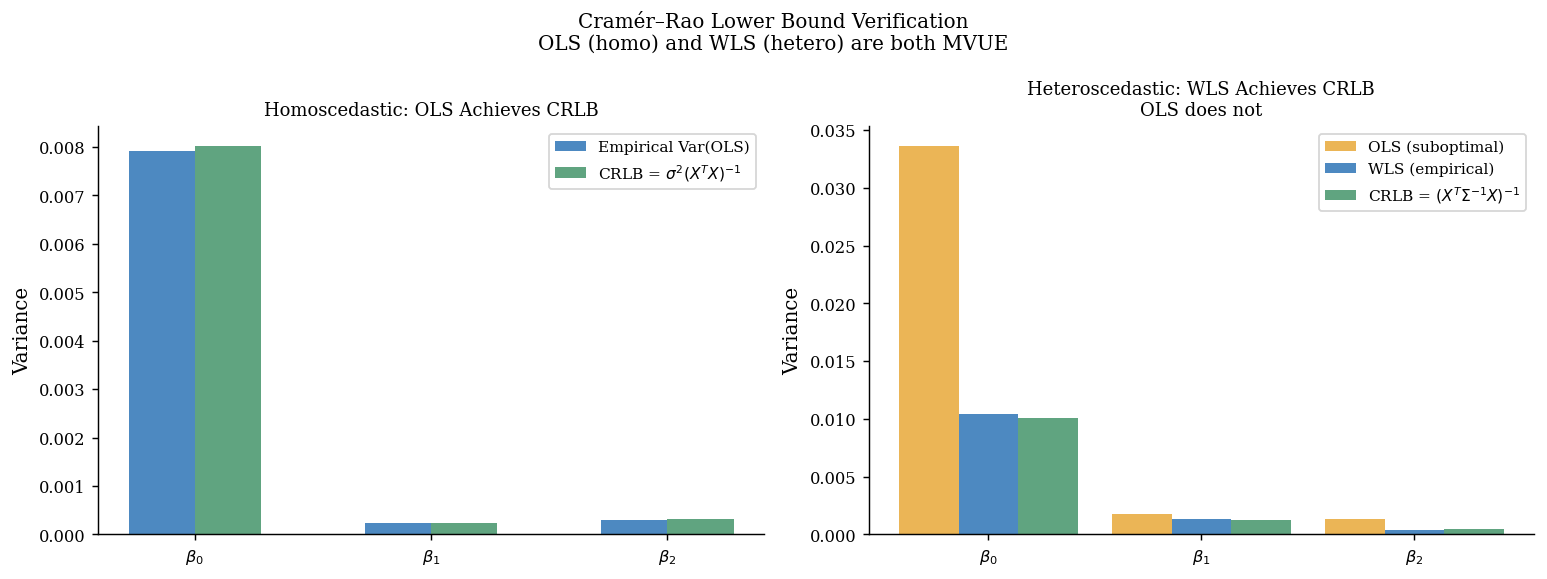

In [23]:
# ── Figure 9: CRLB verification plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x_pos = np.arange(p); w = 0.28

# Left: homoscedastic — OLS vs CRLB
ax = axes[0]
ax.bar(x_pos - w/2, np.var(bhat_ind, axis=0), w,
       color=BLUE,  alpha=0.85, label='Empirical Var(OLS)')
ax.bar(x_pos + w/2, np.diag(CRLB_ols),        w,
       color=GREEN, alpha=0.85, label=r'CRLB = $\sigma^2(X^TX)^{-1}$')
ax.set_xticks(x_pos); ax.set_xticklabels([r'$\beta_0$', r'$\beta_1$', r'$\beta_2$'])
ax.set_ylabel('Variance'); ax.legend(fontsize=8.5)
ax.set_title('Homoscedastic: OLS Achieves CRLB', fontsize=10)

# Right: heteroscedastic — OLS, WLS, CRLB
ax2 = axes[1]
ax2.bar(x_pos - w,  np.var(bhat_ols_h, axis=0), w,
        color=ORANGE, alpha=0.85, label='OLS (suboptimal)')
ax2.bar(x_pos,      np.var(bhat_wls_h, axis=0), w,
        color=BLUE,   alpha=0.85, label='WLS (empirical)')
ax2.bar(x_pos + w,  np.diag(CRLB_wls),          w,
        color=GREEN,  alpha=0.85, label=r'CRLB = $(X^T\Sigma^{-1}X)^{-1}$')
ax2.set_xticks(x_pos); ax2.set_xticklabels([r'$\beta_0$', r'$\beta_1$', r'$\beta_2$'])
ax2.set_ylabel('Variance'); ax2.legend(fontsize=8.5)
ax2.set_title('Heteroscedastic: WLS Achieves CRLB\nOLS does not', fontsize=10)

fig.suptitle(
    'Cramér–Rao Lower Bound Verification\n'
    'OLS (homo) and WLS (hetero) are both MVUE',
    fontsize=11
)
plt.tight_layout()
plt.show()
